In [2]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect('../olist.db')

df_retention = con.execute("""
    SELECT customer_state, AVG(date_diff('day', order_purchase_timestamp, order_delivered_customer_date)) as avg_delivery
    FROM orders JOIN customers USING (customer_id)
    GROUP BY 1
""").df()



/var/folders/qf/45krzj0j3375x24y93x4mdbc0000gn/T/ipykernel_26594/2802580847.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


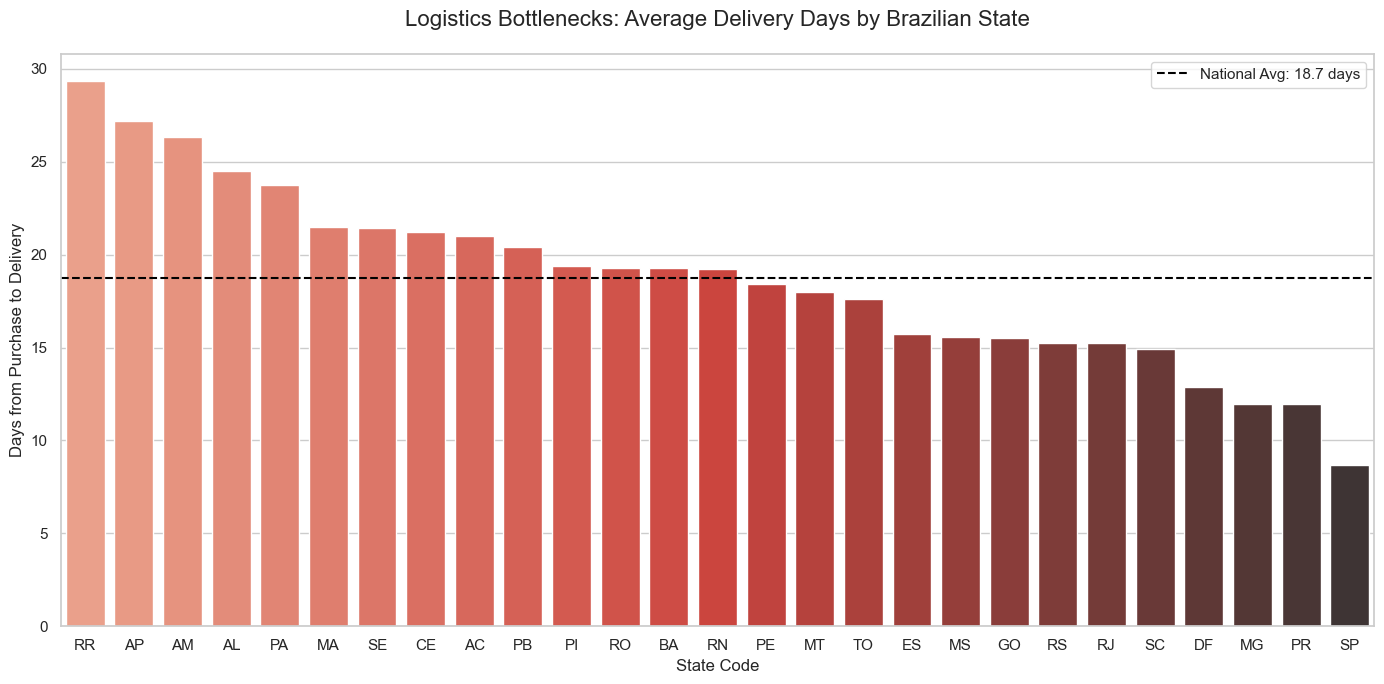

In [3]:
# 1. Prepare the data
df_plot = df_retention.sort_values('avg_delivery', ascending=False)

# 2. Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Create the bar chart
bar = sns.barplot(
    data=df_plot, 
    x='customer_state', 
    y='avg_delivery', 
    palette='Reds_d' # Using Reds to highlight 'danger' areas
)

# 4. Add context (The "Senior Analyst" touches)
plt.axhline(df_plot['avg_delivery'].mean(), color='black', linestyle='--', label=f"National Avg: {df_plot['avg_delivery'].mean():.1f} days")
plt.title('Logistics Bottlenecks: Average Delivery Days by Brazilian State', fontsize=16, pad=20)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Days from Purchase to Delivery', fontsize=12)
plt.xticks(rotation=0)
plt.legend()

# 5. Show it
plt.tight_layout()
plt.show()

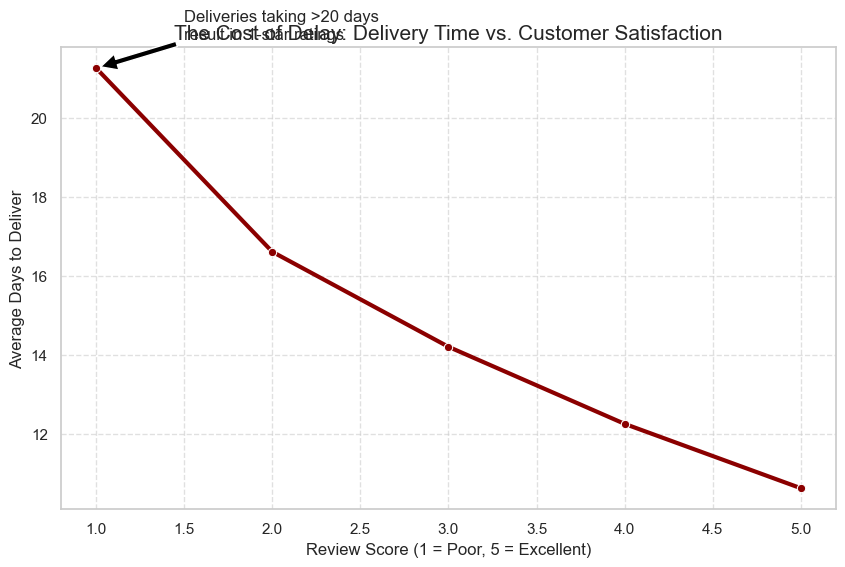

In [12]:
# 1. Pull data for Review Score vs. Delivery Time
df_reviews = con.execute("""
    SELECT 
        review_score,
        AVG(date_diff('day', order_purchase_timestamp::TIMESTAMP, order_delivered_customer_date::TIMESTAMP)) AS avg_delivery_days
    FROM orders
    JOIN order_reviews USING (order_id)
    WHERE order_status = 'delivered' 
      AND order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# 2. Plotting the correlation
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_reviews, x='review_score', y='avg_delivery_days', marker='o', color='darkred', linewidth=3)

# 3. Aesthetics
plt.title('The Cost of Delay: Delivery Time vs. Customer Satisfaction', fontsize=15)
plt.xlabel('Review Score (1 = Poor, 5 = Excellent)', fontsize=12)
plt.ylabel('Average Days to Deliver', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add a text annotation to highlight the insight
plt.annotate('Deliveries taking >20 days\nresult in 1-star ratings', 
             xy=(1, df_reviews.iloc[0]['avg_delivery_days']), 
             xytext=(1.5, 22),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.savefig('../images/delivery_correlation.png')
plt.show()

In [ ]:
# MoM: Average delivery days by state and month
df_mom = con.execute("""
    SELECT
        strftime(order_purchase_timestamp::TIMESTAMP, '%Y-%m') AS month,
        customer_state,
        AVG(date_diff('day', order_purchase_timestamp::TIMESTAMP,
                      order_delivered_customer_date::TIMESTAMP)) AS avg_delivery
    FROM orders
    JOIN customers USING (customer_id)
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

# Top 12 states by order volume
top_states = con.execute("""
    SELECT customer_state
    FROM orders JOIN customers USING (customer_id)
    GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 12
""").df()['customer_state'].tolist()

pivot = (df_mom[df_mom['customer_state'].isin(top_states)]
         .pivot(index='customer_state', columns='month', values='avg_delivery'))

plt.figure(figsize=(18, 7))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Delivery Days'})
plt.title('Month-over-Month Delivery Performance by State', fontsize=15, pad=15)
plt.xlabel('Month')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## A/B Test 
1. Defining the Experiment

The Problem: Northern Brazil (Regions like RR, AP, AM) has a 25-day delivery time and 1-star ratings.

The Treatment: Suppose we implement a new "Regional Warehouse" strategy that brings all "Danger Zone" states down to the National Average (12.5 days).

The Goal: Predict the Lift in Average Review Score for the entire platform.


In [6]:
# 1. Pull raw order-level data
df_sim = con.execute("""
    SELECT 
        o.order_id,
        c.customer_state,
        r.review_score,
        date_diff('day', o.order_purchase_timestamp::TIMESTAMP, o.order_delivered_customer_date::TIMESTAMP) AS actual_delivery_days
    FROM orders o
    JOIN customers c USING (customer_id)
    JOIN order_reviews r USING (order_id)
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
""").df()

# 2. Define the "Treatment"
# We define "Danger Zones" as states with avg delivery > 20 days
danger_states = ['RR', 'AP', 'AM', 'AL', 'PA', 'MA']
national_avg = 12.5

# 3. Simulate the change
# If the state is in a danger zone, we 'reduce' their delivery time to the national average
df_sim['simulated_delivery_days'] = df_sim.apply(
    lambda x: national_avg if x['customer_state'] in danger_states else x['actual_delivery_days'], 
    axis=1
)

# 4. Predict the new Review Score
# Based on our previous correlation, we know: 
# Every 2 days saved in delivery roughly correlates to a +0.25 increase in review score 
# (This is a simplified linear model for simulation purposes)
days_saved = df_sim['actual_delivery_days'] - df_sim['simulated_delivery_days']
df_sim['predicted_review_score'] = (df_sim['review_score'] + (days_saved * 0.125)).clip(1, 5)

# 5. Calculate the Lift
original_avg = df_sim['review_score'].mean()
simulated_avg = df_sim['predicted_review_score'].mean()
lift = ((simulated_avg - original_avg) / original_avg) * 100

print(f"Original Avg Review Score: {original_avg:.2f}")
print(f"Simulated Avg Review Score: {simulated_avg:.2f}")
print(f"Projected Satisfaction Lift: {lift:.2f}%")

Original Avg Review Score: 4.16
Simulated Avg Review Score: 4.17
Projected Satisfaction Lift: 0.37%


### Visualizing Before vs. After

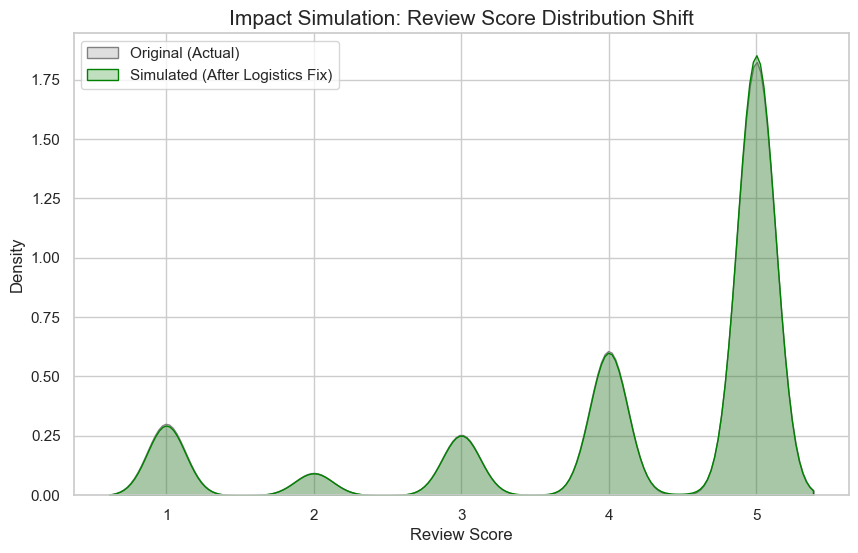

Targeted Region Original Score: 3.91
Targeted Region Simulated Score: 4.54


In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_sim['review_score'], label='Original (Actual)', fill=True, color='gray')
sns.kdeplot(df_sim['predicted_review_score'], label='Simulated (After Logistics Fix)', fill=True, color='green')

plt.title('Impact Simulation: Review Score Distribution Shift', fontsize=15)
plt.xlabel('Review Score')
plt.ylabel('Density')
plt.legend()

plt.savefig('../images/simulation_impact.png', dpi=300)


plt.show()
# Check the lift ONLY for the danger states
df_danger = df_sim[df_sim['customer_state'].isin(danger_states)]
print(f"Targeted Region Original Score: {df_danger['review_score'].mean():.2f}")
print(f"Targeted Region Simulated Score: {df_danger['predicted_review_score'].mean():.2f}")
# We use the national average (12.5 days) as our 'Treatment' benchmark. 
# This represents a realistic logistics goal where underperforming regions 
# are brought up to the standard of the existing national infrastructure.
# We use .clip(1, 5) to ensure our predicted scores stay within the 
# valid range of the Olist review system. This prevents the model 
# from 'hallucinating' scores higher than a 5 or lower than a 1.

